In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd
import numpy as np
import os, math

os.chdir('../../../results/PlantCAD2_tasks/accessible_angiosperm_c600/data_leave_out_zma_hvu/')

In [2]:
species  = ['hordeum_vulgare','zea_mays']
ckpts = [
    'pcv2-l24-d0768-checkpoints-lr-1e-4',
    'pcv2-l48-d1024-checkpoints-lr-1e-4',
    'pcv2-l48-d1536-checkpoints-lr-1e-4',
    'agront-checkpoints-lr-1e-4',
    'sup_pcv2-l24-d0768-checkpoints-lr-1e-4',
    'cnn-lstm-imbalance-lr-1e-3'
]
pcv2_alphas = [0.4, 0.7, 1.0]

In [3]:
records = []
for sp in species:
    labels_path = f'data/test_{sp}.tsv'
    labs = pd.read_csv(labels_path, sep='\t')
    y_true = labs['Label']

    for k, ckpt in enumerate(ckpts):
        print(f"[{sp}] Processing model {k+1}/{len(ckpts)}: {ckpt}")
        scores_path = f'models/{ckpt}/test_{sp}_scores.tsv'
        preds = pd.read_csv(scores_path, sep='\t')
        y_scores = preds['probability_positive']
        ap = average_precision_score(y_true, y_scores)

        if 'agront' in ckpt.lower():
            color, alpha = 'gray', 1.0
        elif 'sup_pcv2' in ckpt.lower():
            color, alpha = 'C1', 1.0
        elif 'cnn' in ckpt.lower():
            color, alpha = 'C1', 0.5
        else:
            color, alpha = 'C0', pcv2_alphas[k]

        if 'cnn' in ckpt.lower():
            lab = ckpt.replace('-imbalance-lr-1e-3', '')
        else:
            lab = ckpt.replace('-checkpoints-lr-1e-4', '')

        records.append({
            'species': sp,
            'model': lab,
            'ap': ap,
            'color': color,
            'alpha': alpha,
            'baseline': y_true.mean()
        })

df = pd.DataFrame(records)

[hordeum_vulgare] Processing model 1/6: pcv2-l24-d0768-checkpoints-lr-1e-4
[hordeum_vulgare] Processing model 2/6: pcv2-l48-d1024-checkpoints-lr-1e-4
[hordeum_vulgare] Processing model 3/6: pcv2-l48-d1536-checkpoints-lr-1e-4
[hordeum_vulgare] Processing model 4/6: agront-checkpoints-lr-1e-4
[hordeum_vulgare] Processing model 5/6: sup_pcv2-l24-d0768-checkpoints-lr-1e-4
[hordeum_vulgare] Processing model 6/6: cnn-lstm-imbalance-lr-1e-3


/tmp/ipykernel_3907820/1710340134.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  labs = pd.read_csv(labels_path, sep='\t')


[zea_mays] Processing model 1/6: pcv2-l24-d0768-checkpoints-lr-1e-4
[zea_mays] Processing model 2/6: pcv2-l48-d1024-checkpoints-lr-1e-4
[zea_mays] Processing model 3/6: pcv2-l48-d1536-checkpoints-lr-1e-4
[zea_mays] Processing model 4/6: agront-checkpoints-lr-1e-4
[zea_mays] Processing model 5/6: sup_pcv2-l24-d0768-checkpoints-lr-1e-4
[zea_mays] Processing model 6/6: cnn-lstm-imbalance-lr-1e-3


In [4]:
df.to_csv('../../../../pipelines/lu_2019_ATACseq/figures/leave_zma_hvu_AUPRC.tsv', sep='\t', index=False)

In [5]:
models = df['model'].unique()
n_models = len(models)

species_order = [sp for sp in species if sp in df['species'].unique()]
n_sp = len(species_order)

bar_w = 0.8 / n_models
x = np.arange(n_sp)

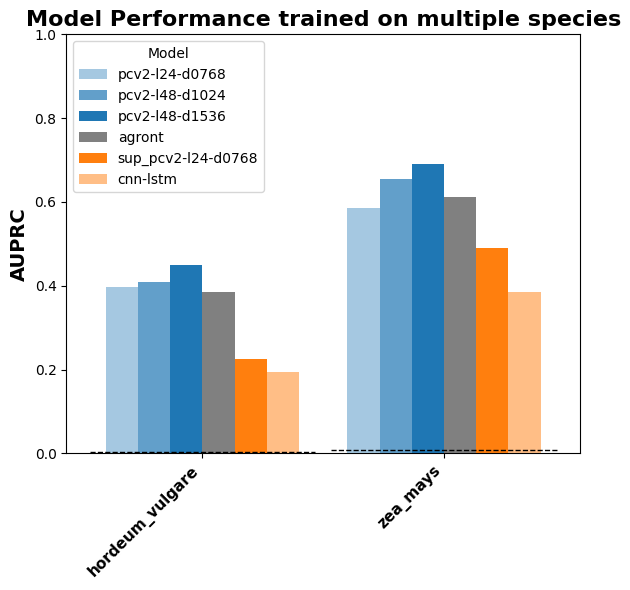

In [6]:
fig, ax = plt.subplots(figsize=(5 + 0.5 * n_sp, 6))

for i, model in enumerate(models):
    sub = df[df['model'] == model]
    sub = sub.set_index('species').reindex(species_order).reset_index()

    ax.bar(
        x + i * bar_w,
        sub['ap'],
        bar_w,
        label=model,
        color=sub['color'].iloc[0] if not sub.empty else 'gray',
        alpha=sub['alpha'].iloc[0] if not sub.empty else 0.5
    )

for j, sp in enumerate(species_order):
    sub = df[df['species'] == sp]
    if not sub.empty:
        baseline = sub['baseline'].iloc[0]
        ax.hlines(baseline,
                  x[j] - bar_w,
                  x[j] + bar_w * n_models,
                  colors='black', linestyles='--', linewidth=1)

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(species_order, rotation=45, ha='right', fontsize=11, fontweight='bold')

ax.set_ylabel('AUPRC', fontsize=14, fontweight='bold')
ax.set_title(f'Model Performance trained on multiple species', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(title='Model', fontsize=10)

plt.tight_layout()
plt.savefig('../../../../pipelines/lu_2019_ATACseq/figures/aupr_barplot_c600_leave_zma_hvu.pdf', format='pdf', bbox_inches='tight')